# N-pulse deadtime sweep
Extended view that mixes the original double-pulse runs with the new 3- and 4-pulse data. Use the `DeadtimeAnalysis` helper to slice by pulser rate and pulse count so we can see how the response shifts as we increase the number of pulses in the sequence.

In [1]:

from pathlib import Path
import sys

ROOT = Path.cwd().resolve().parent
sys.path.append(str(ROOT / 'src'))

from deadtime_analysis import DeadtimeAnalysis

DATA_FILES = [
    ROOT / 'data' / 'combined_deadtime.jsonl',
]
analysis = DeadtimeAnalysis.from_jsonl([str(p) for p in DATA_FILES])
PULSER_RATES = sorted(analysis.df['pulse_rate_hz'].unique())
PULSE_COUNTS = sorted([int(x) for x in analysis.df['num_pulses'].dropna().unique()])
analysis.df[['pulse_rate_hz', 'num_pulses', 'separation_ns', 'observed_rate_hz', 'observed_ratio_vs_expected']].head()


,pulse_rate_hz,num_pulses,separation_ns,observed_rate_hz,observed_ratio_vs_expected
0,10.0,2,500,9.33,0.4665
1,10.0,2,500,9.33,0.4665
17,10.0,2,500,9.33,0.4665
33,10.0,2,500,9.33,0.4665
49,10.0,2,500,10.00,0.5000


## Observed rate vs. separation by pulse count
- Filters each plot to a single pulse count so we don't mix double / triple / quad runs on the same line.
- Use these to spot where the observed rates fall relative to the pulser rate as we increase the number of pulses.

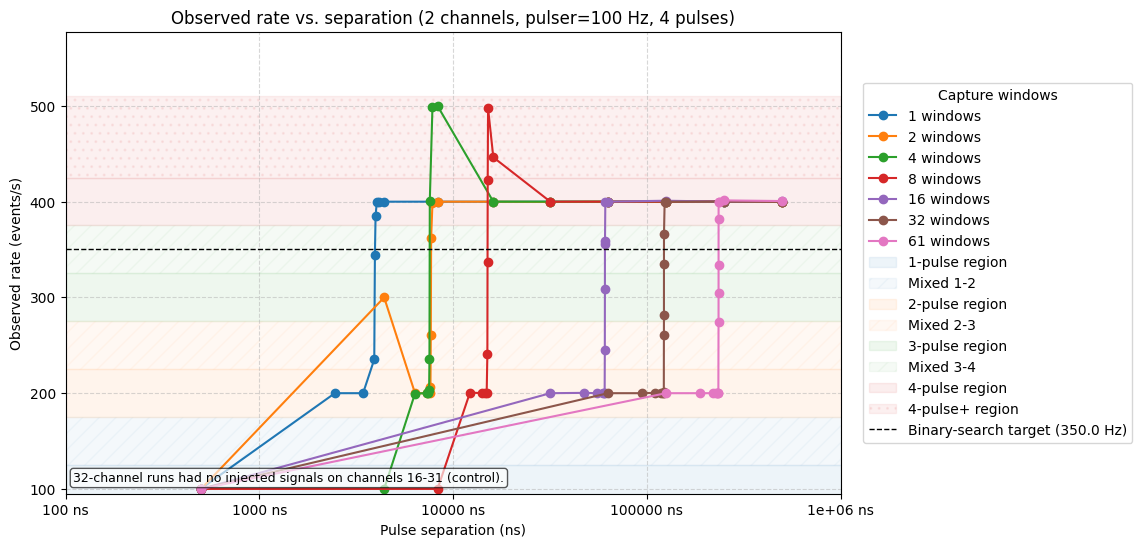

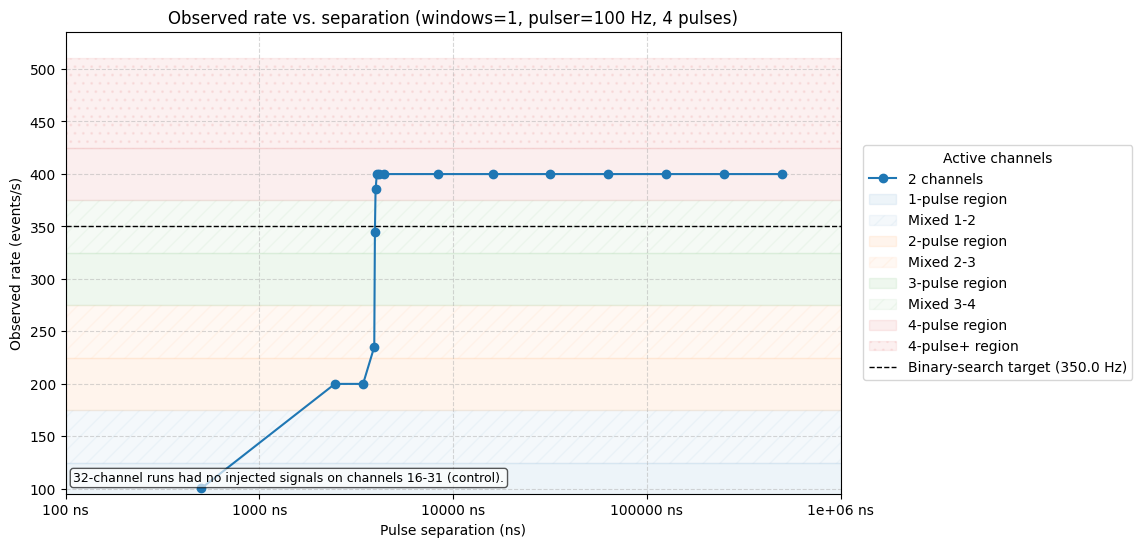

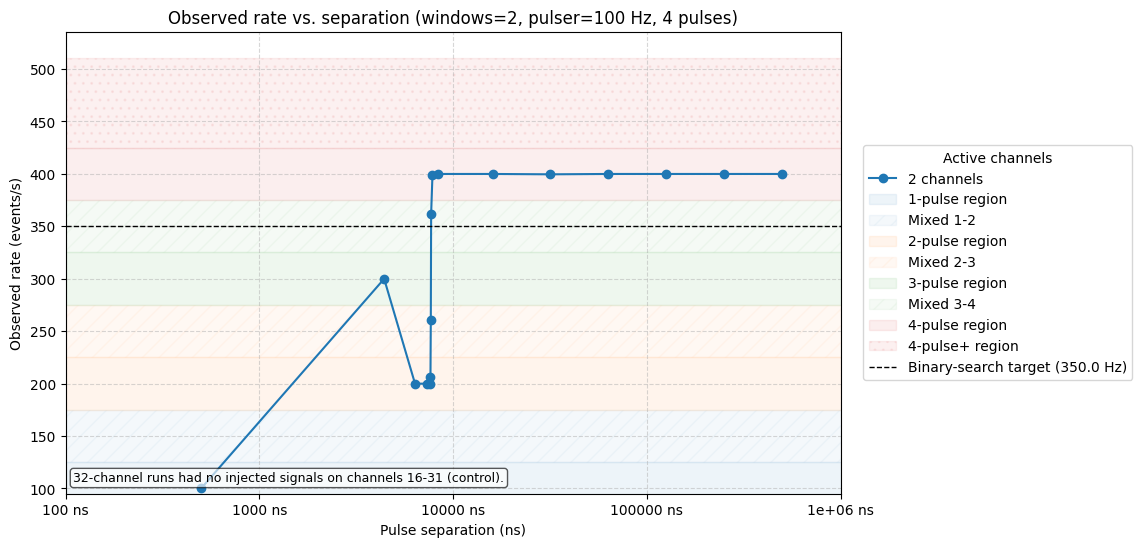

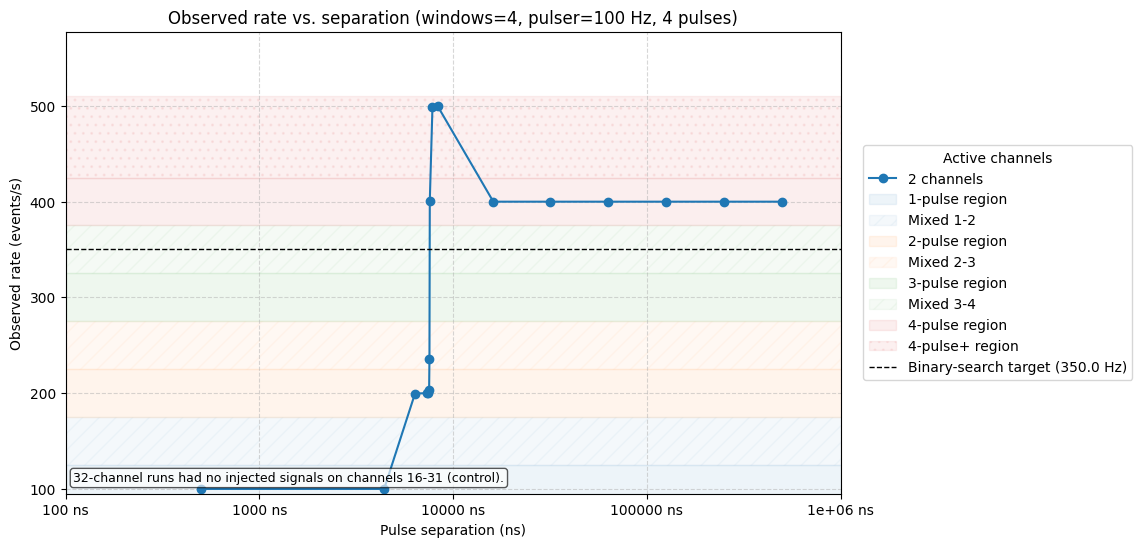

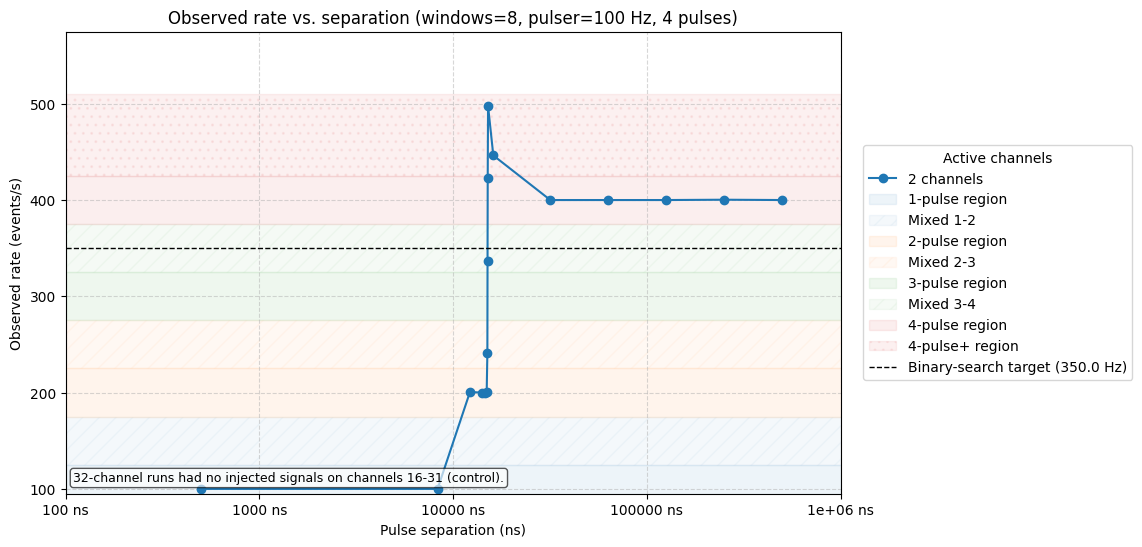

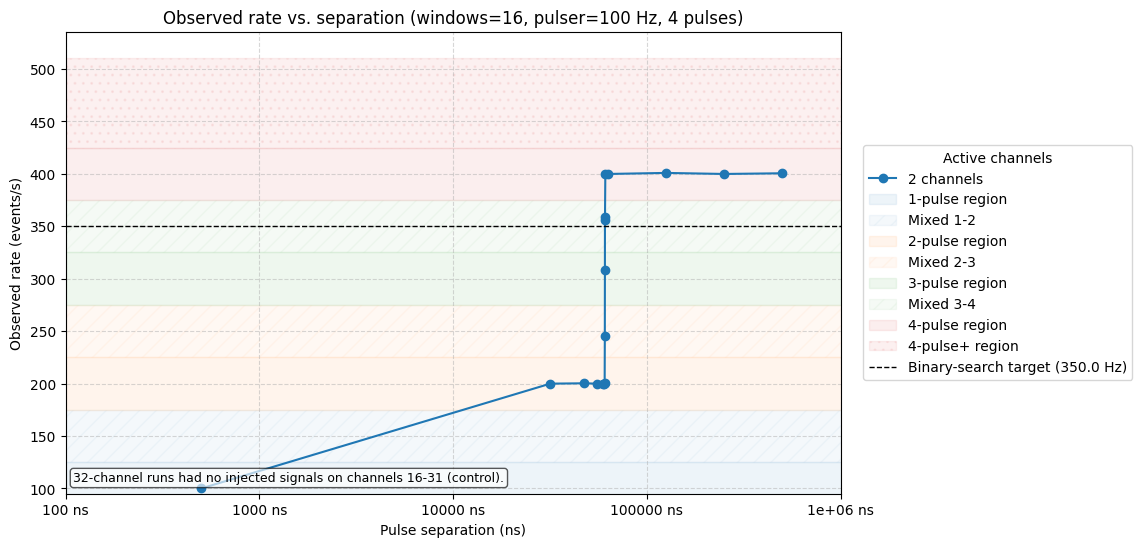

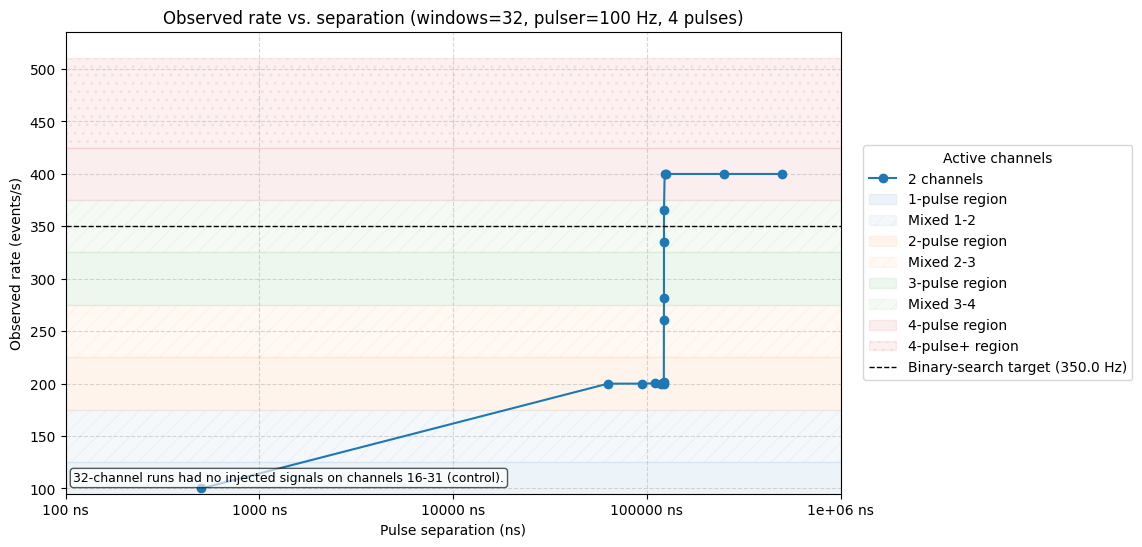

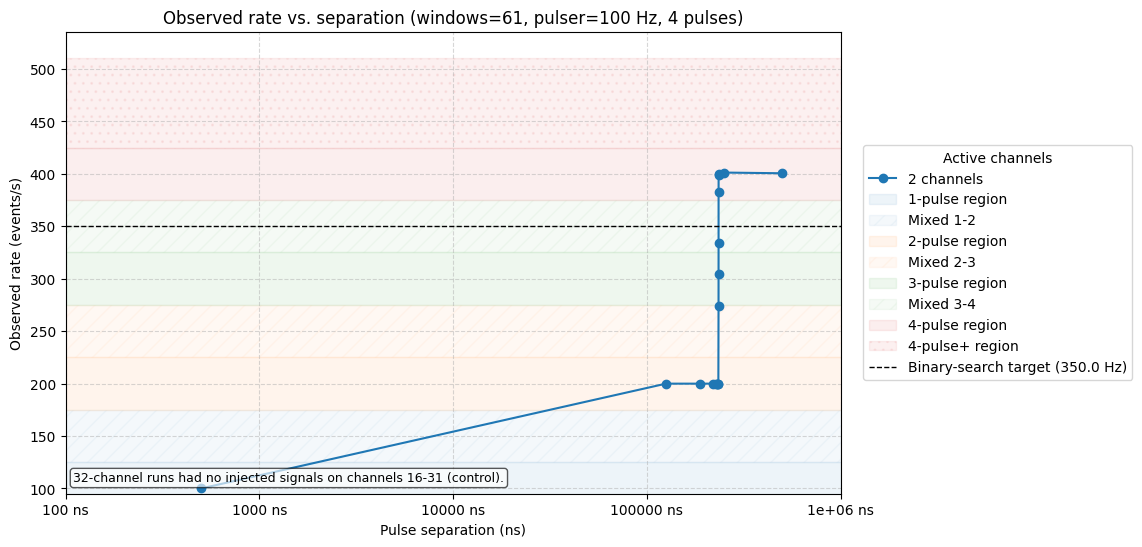

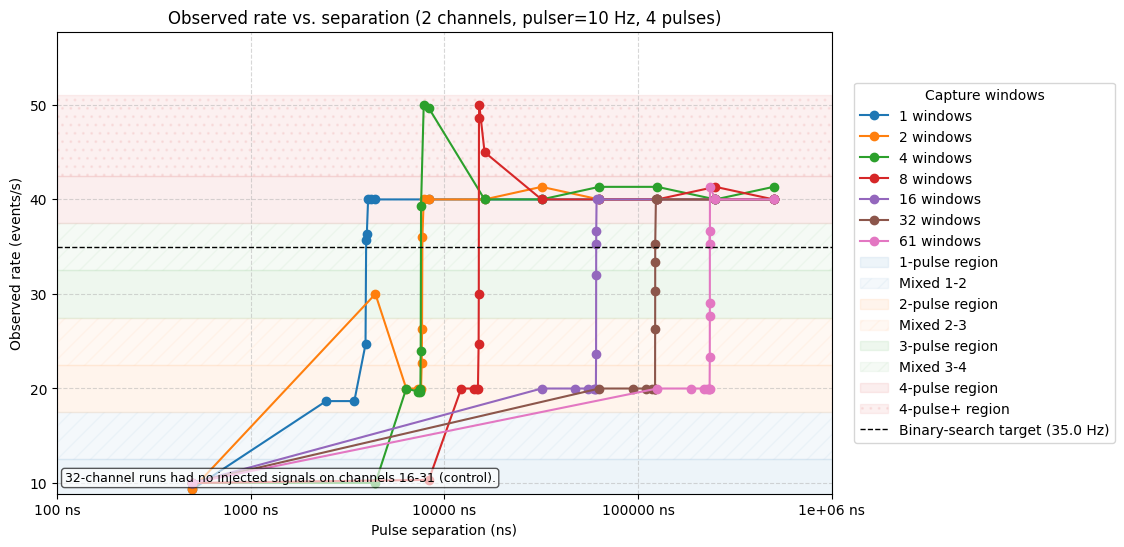

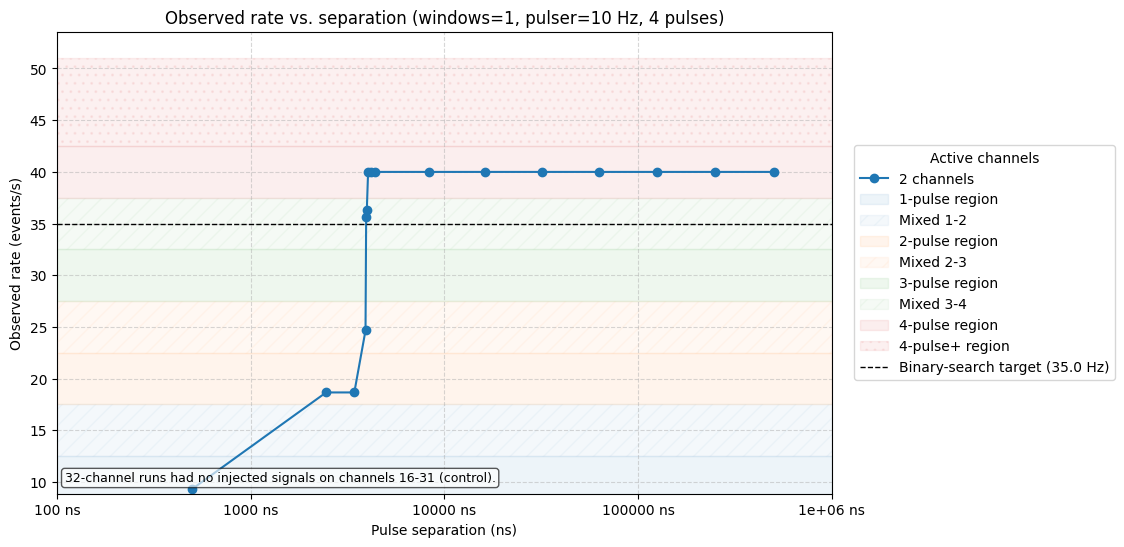

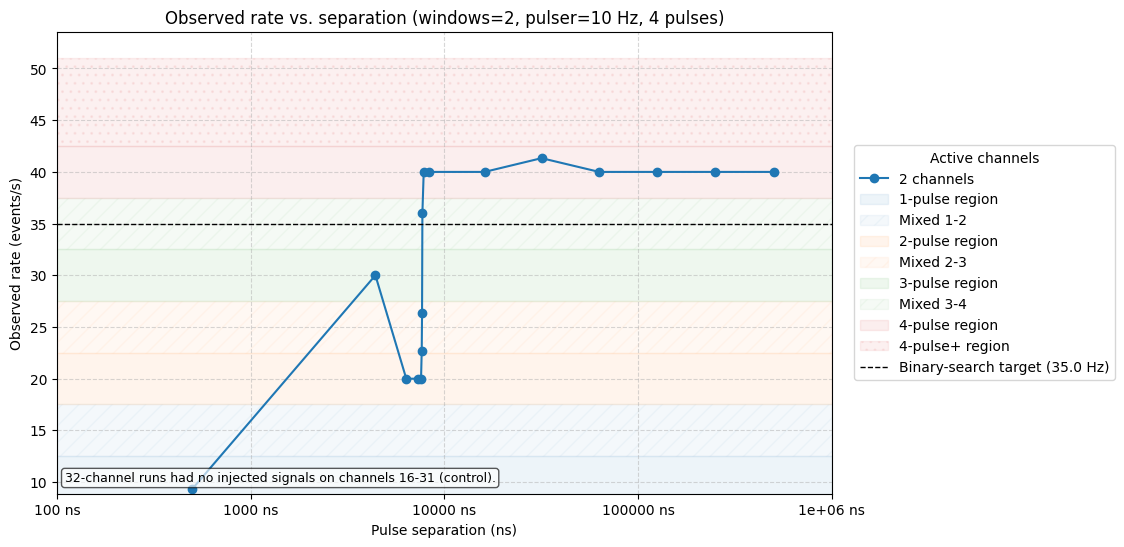

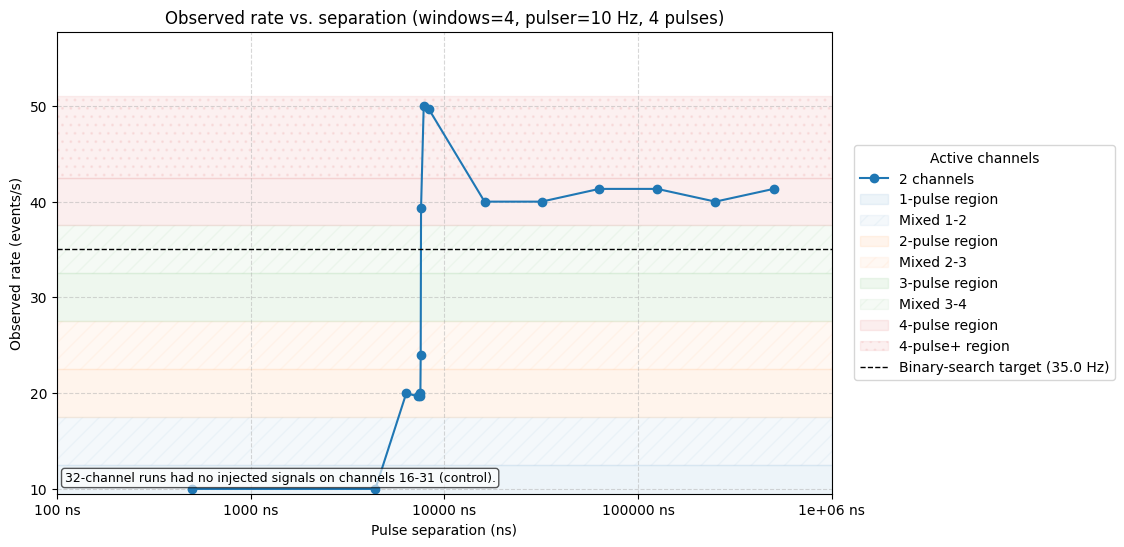

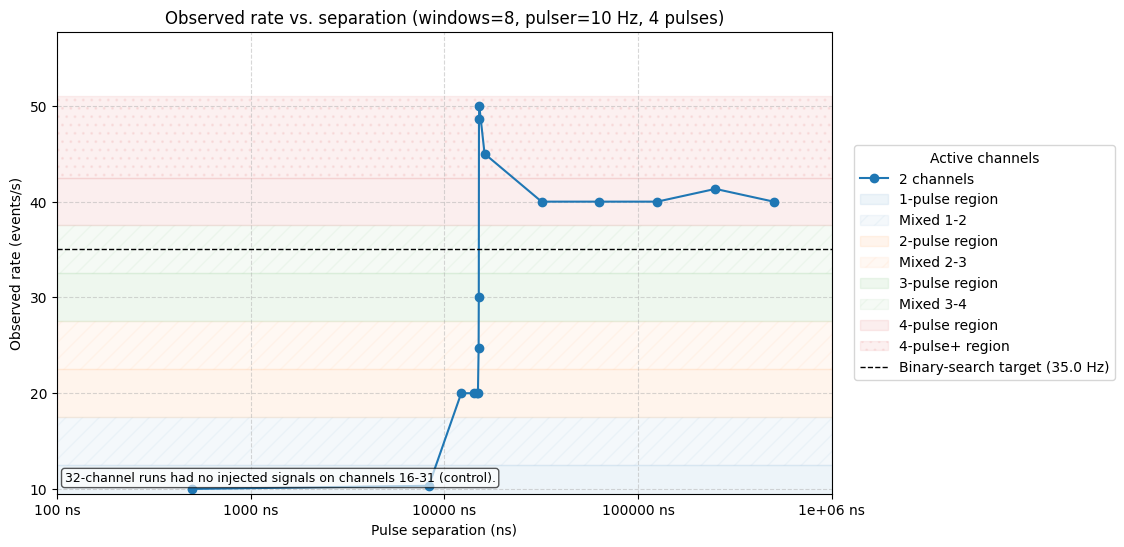

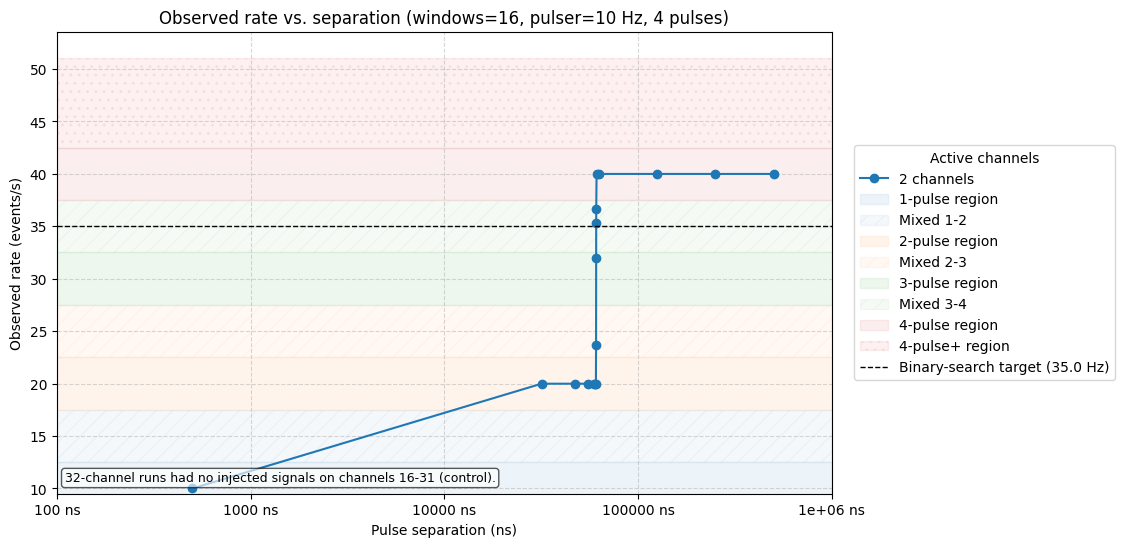

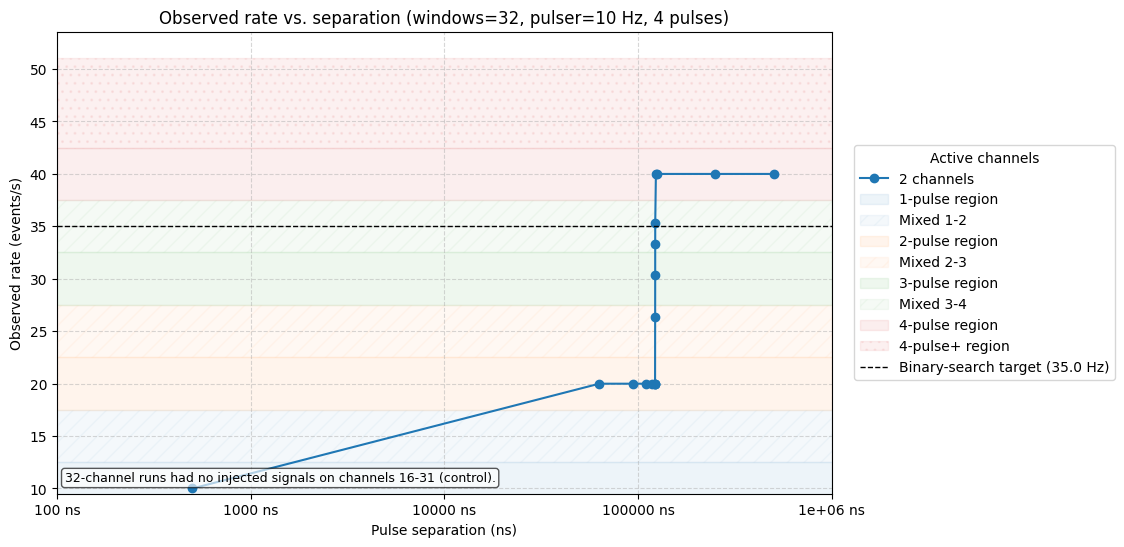

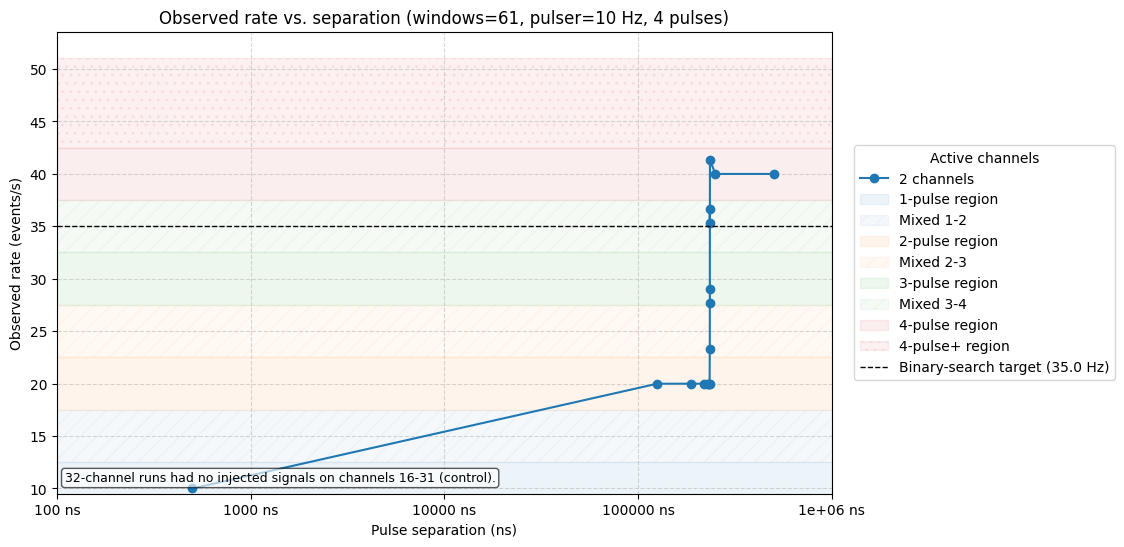

In [2]:

# Plot a few representative combinations to keep runtime manageable
# Each combo can optionally pin channel_count and windows; None means include all.
EXAMPLE_COMBOS = [
    {"rate": 100.0, "num_pulses": 4, "channels": 2, "windows": None},
    {"rate": 10.0, "num_pulses": 4, "channels": 2, "windows": None},
    # Add more like {"rate": 10.0, "num_pulses": 3, "channels": 1, "windows": 1}
]

for combo in EXAMPLE_COMBOS:
    rate = combo.get("rate")
    num_pulses = combo.get("num_pulses")
    channels = combo.get("channels")
    windows = combo.get("windows")
    df_filtered = analysis.df.copy()
    if rate is not None:
        df_filtered = df_filtered[df_filtered["pulse_rate_hz"] == rate]
    if num_pulses is not None:
        df_filtered = df_filtered[df_filtered["num_pulses"] == num_pulses]
    if channels is not None:
        df_filtered = df_filtered[df_filtered["channel_count"] == channels]
    if windows is not None:
        df_filtered = df_filtered[df_filtered["windows"] == windows]
    if df_filtered.empty:
        continue
    ana = DeadtimeAnalysis(df_filtered, single_factor=analysis.single_factor, double_factor=analysis.double_factor)
    try:
        ana.plot_rate_vs_separation_by_channels(rate, num_pulses=num_pulses)
        ana.plot_rate_vs_separation_by_windows(rate, num_pulses=num_pulses)
    except ValueError:
        continue


## Tertiary outcomes by pulse count
Categorical view (single / mixed / double) for each pulse count and pulser rate.

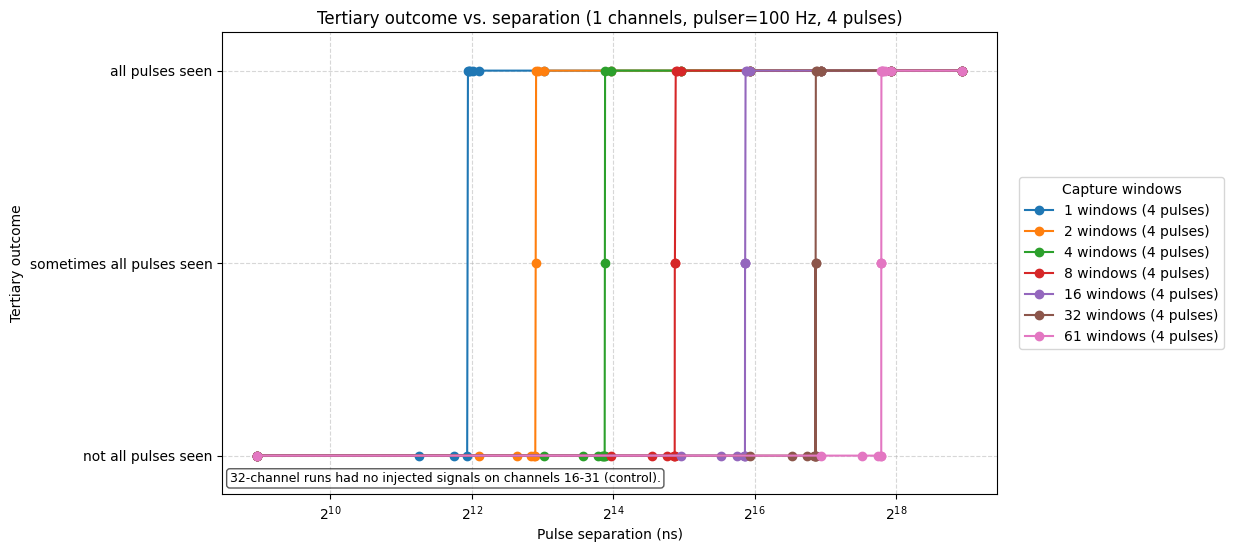

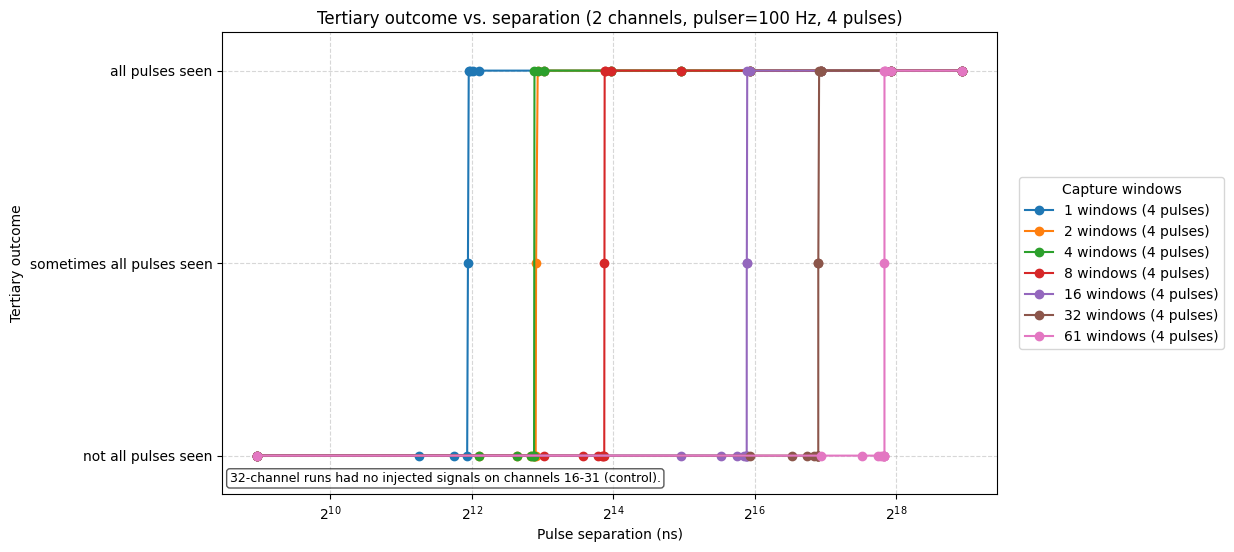

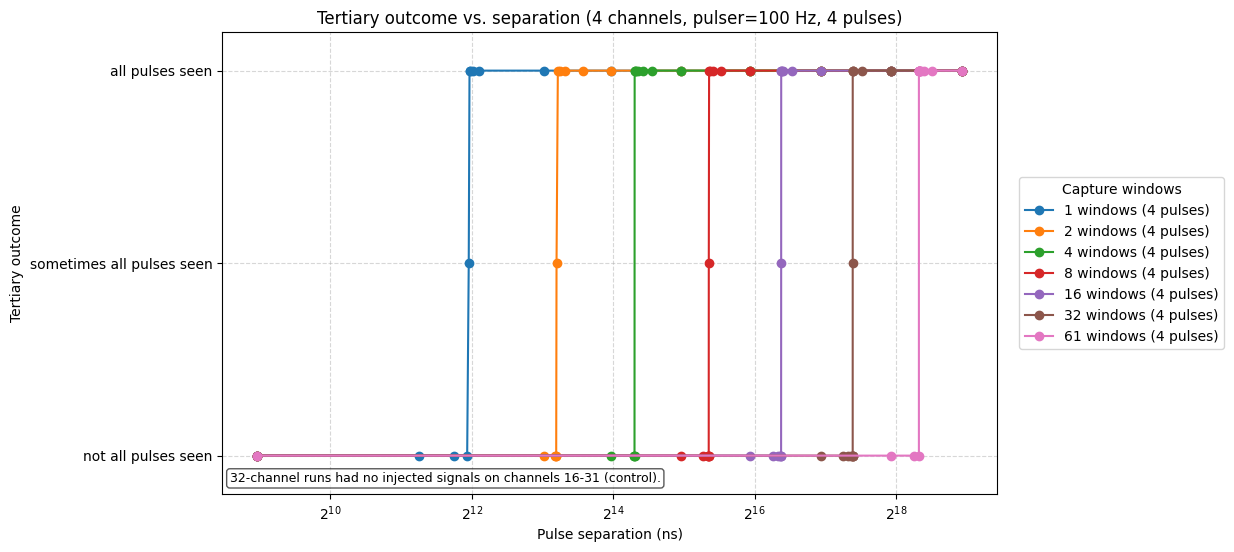

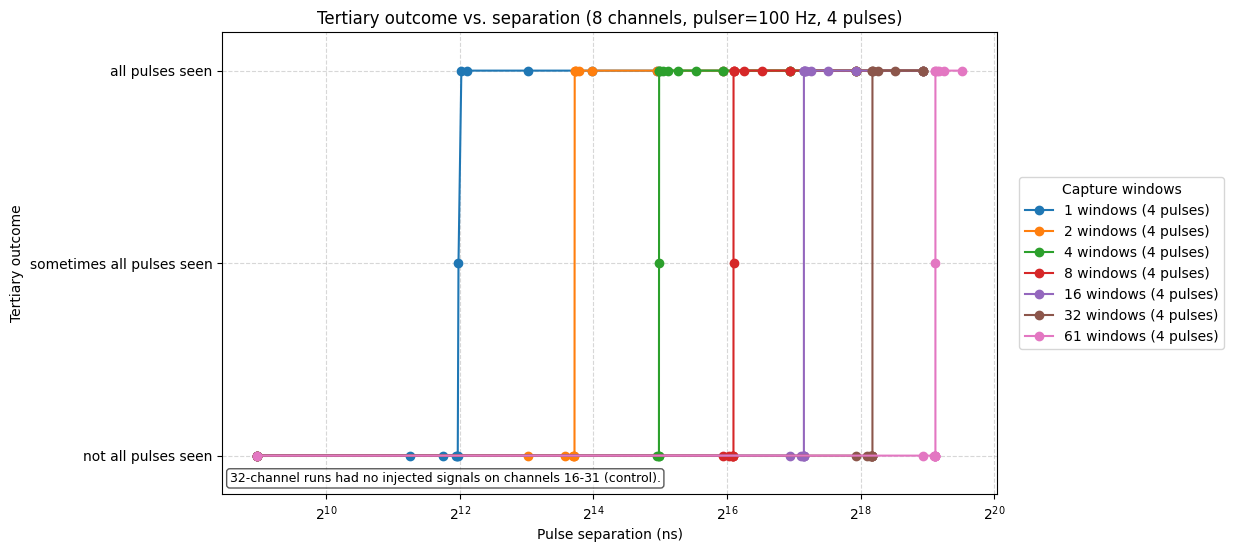

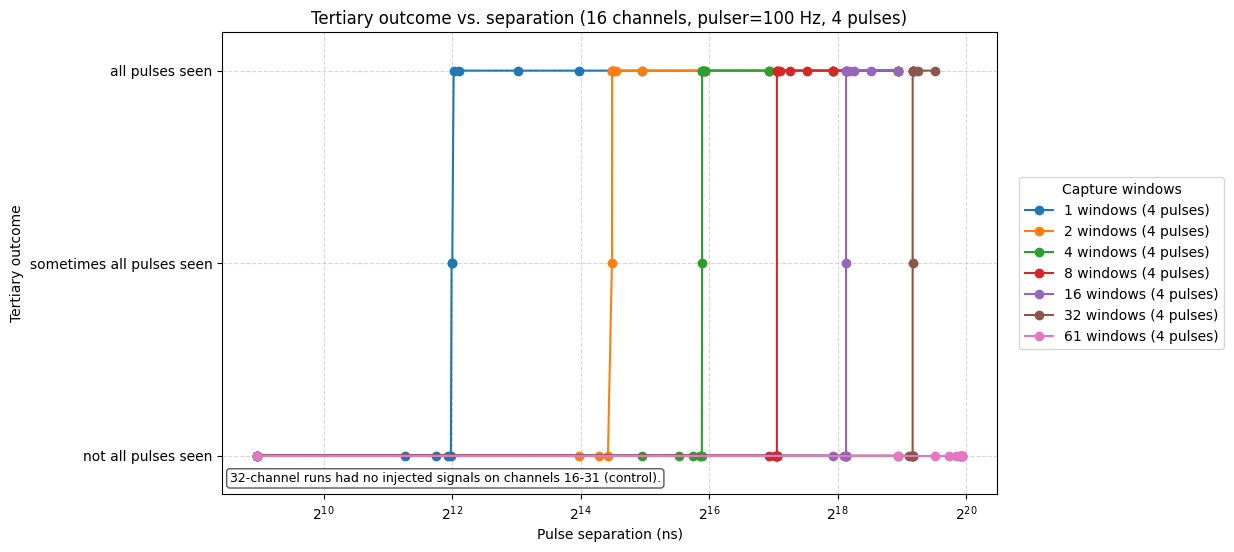

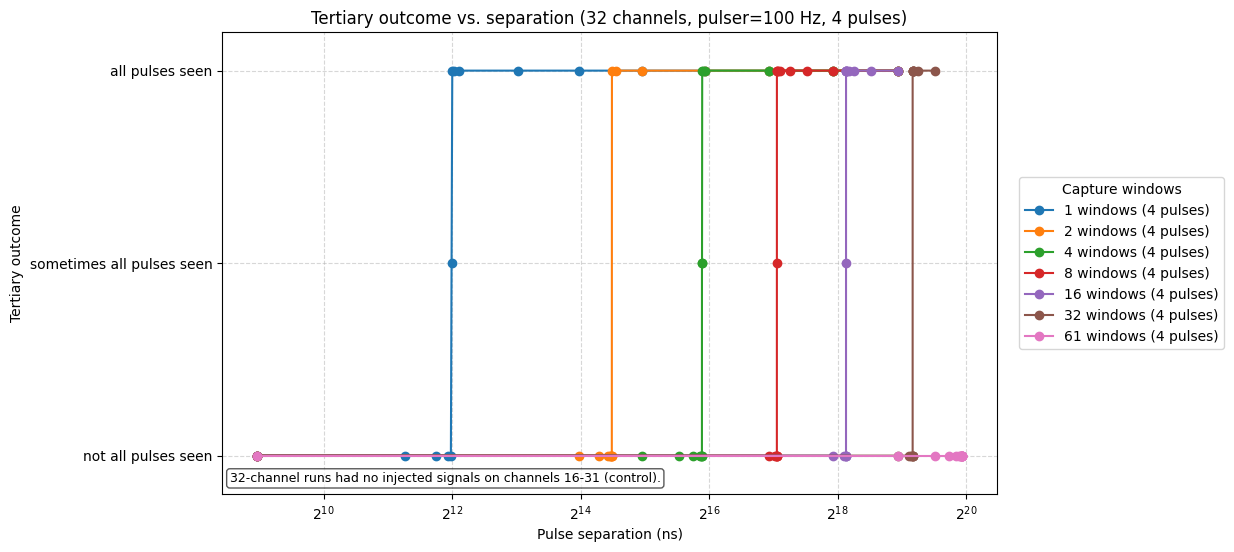

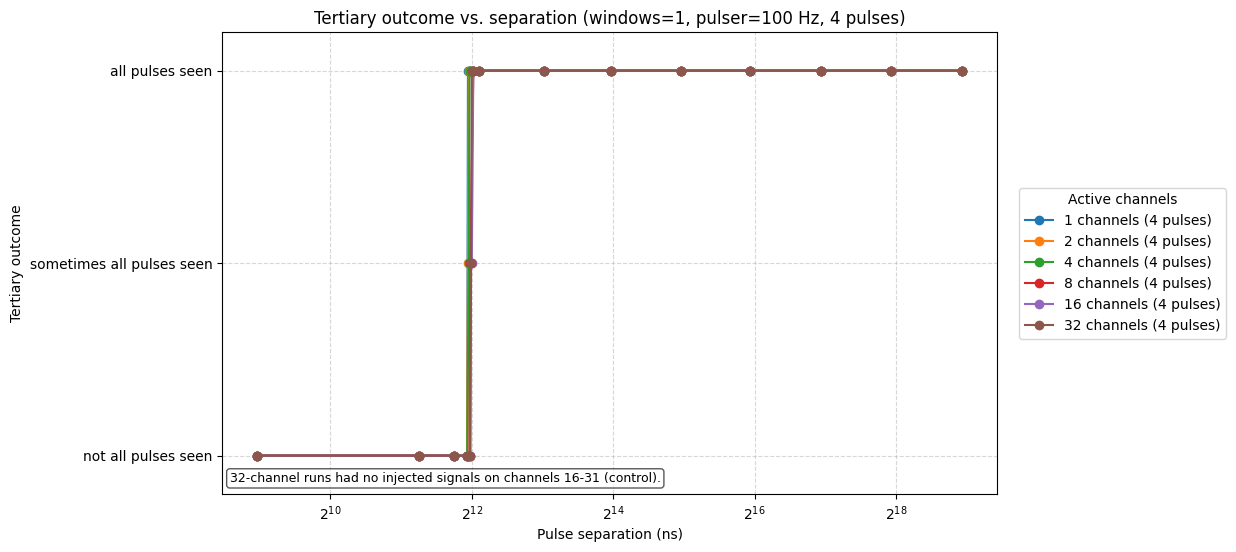

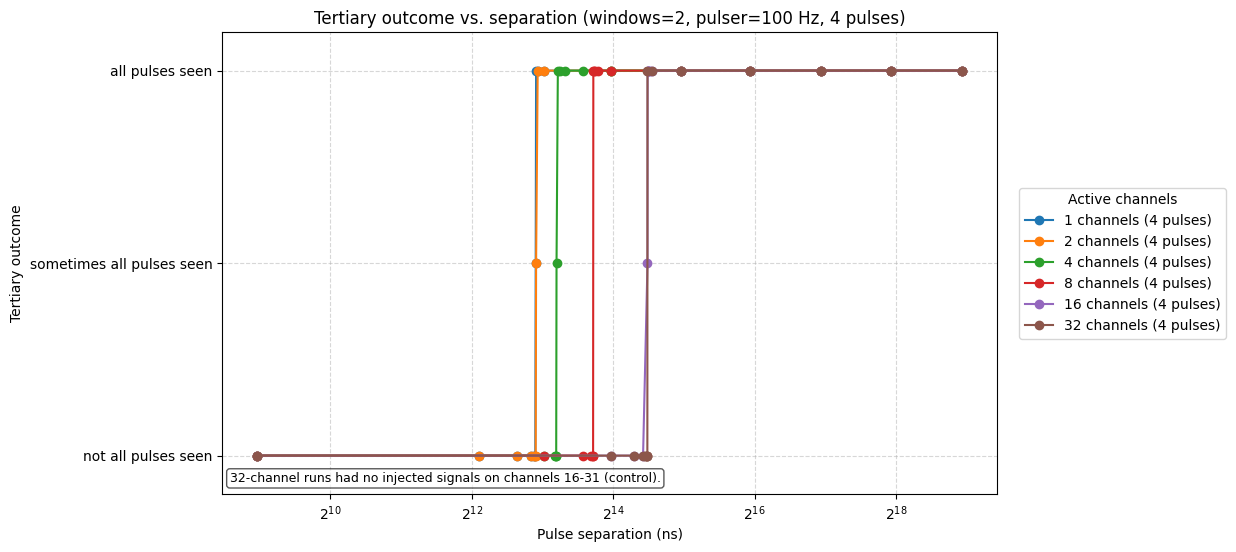

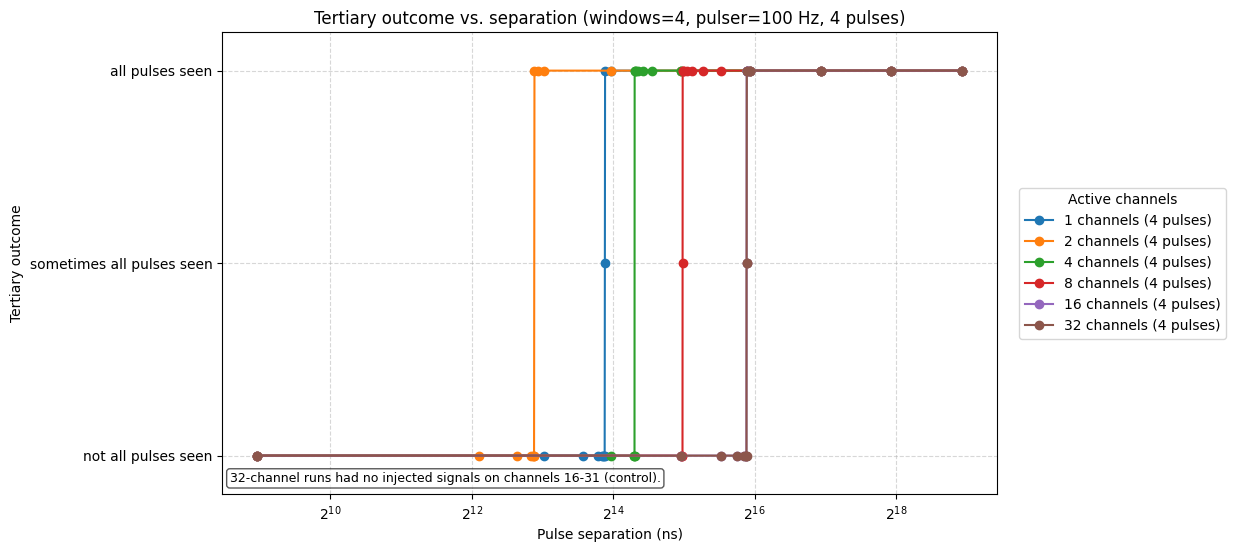

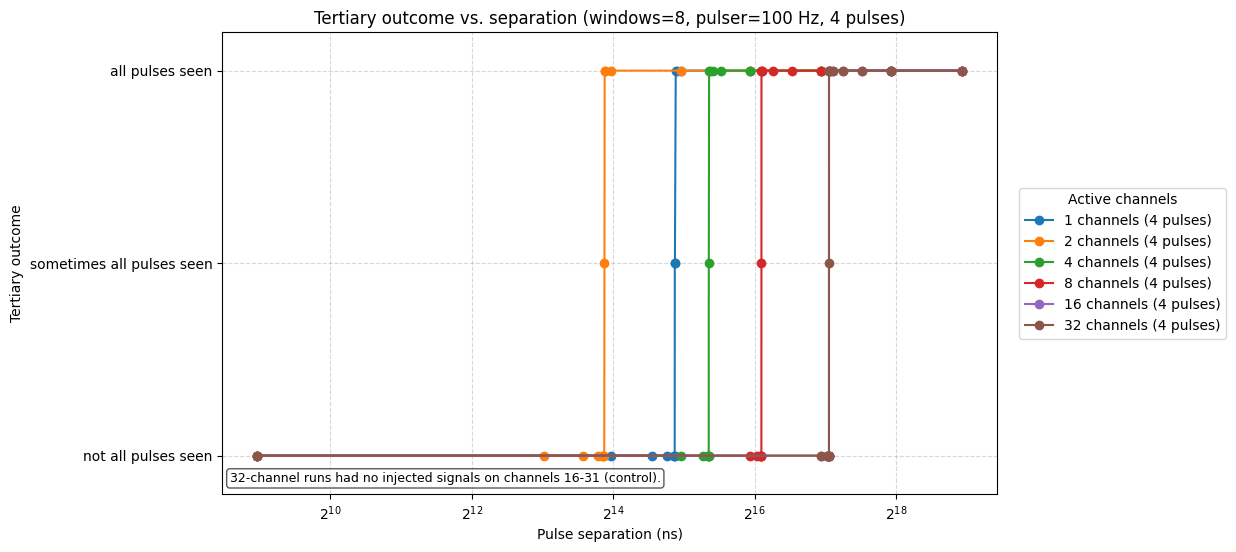

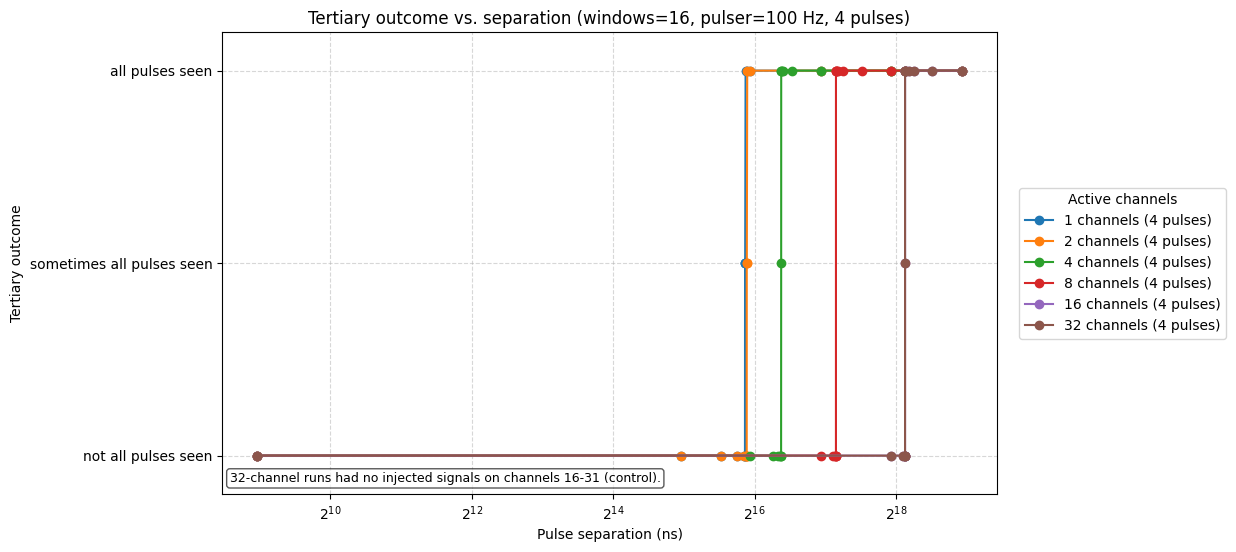

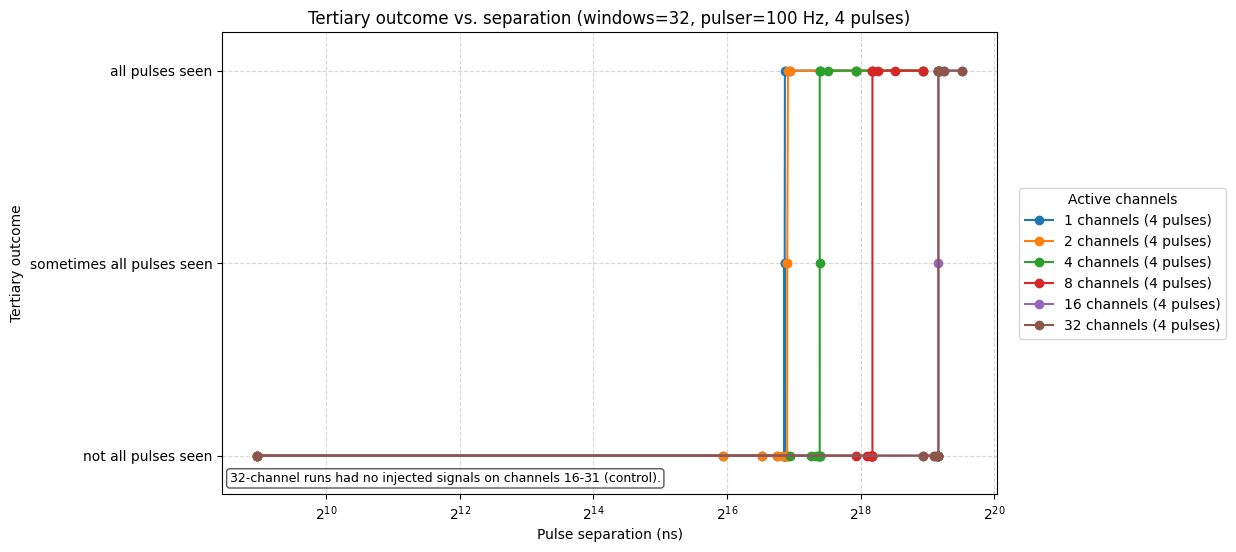

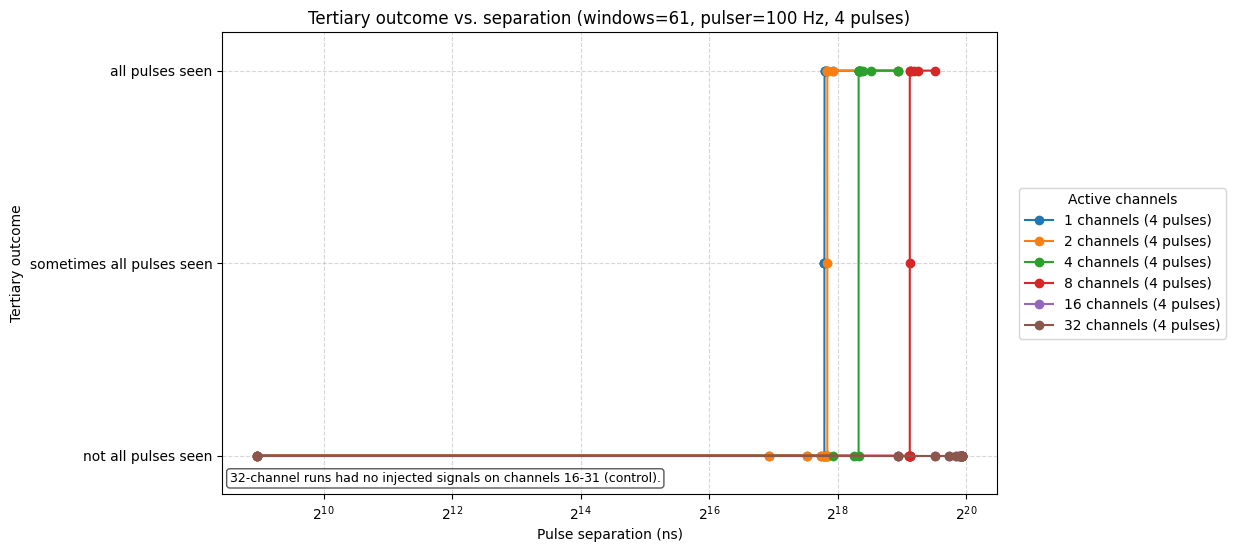

In [3]:

# Tertiary outcomes for the same representative combinations
EXAMPLE_COMBOS = [
    {"rate": 100.0, "num_pulses": 4, "channels": None, "windows": None},
]

for combo in EXAMPLE_COMBOS:
    rate = combo.get("rate")
    num_pulses = combo.get("num_pulses")
    channels = combo.get("channels")
    windows = combo.get("windows")
    df_filtered = analysis.df.copy()
    if rate is not None:
        df_filtered = df_filtered[df_filtered["pulse_rate_hz"] == rate]
    if num_pulses is not None:
        df_filtered = df_filtered[df_filtered["num_pulses"] == num_pulses]
    if channels is not None:
        df_filtered = df_filtered[df_filtered["channel_count"] == channels]
    if windows is not None:
        df_filtered = df_filtered[df_filtered["windows"] == windows]
    if df_filtered.empty:
        continue
    ana = DeadtimeAnalysis(df_filtered, single_factor=analysis.single_factor, double_factor=analysis.double_factor)
    try:
        ana.plot_tertiary_vs_separation_by_channels(rate, num_pulses=num_pulses)
        ana.plot_tertiary_vs_separation_by_windows(rate, num_pulses=num_pulses)
    except ValueError:
        continue


## Converged separation vs. windows/channels (by pulse count)
Includes all pulser rates but keeps series separated by the pulse count so we can see how the converged deadtime moves when we add more pulses to the sequence.

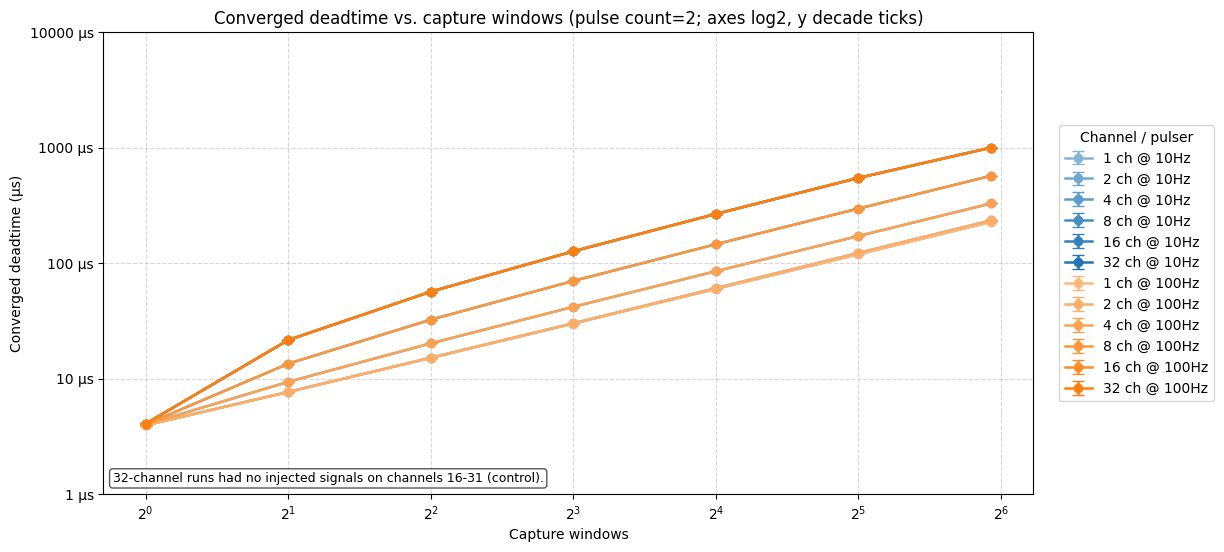

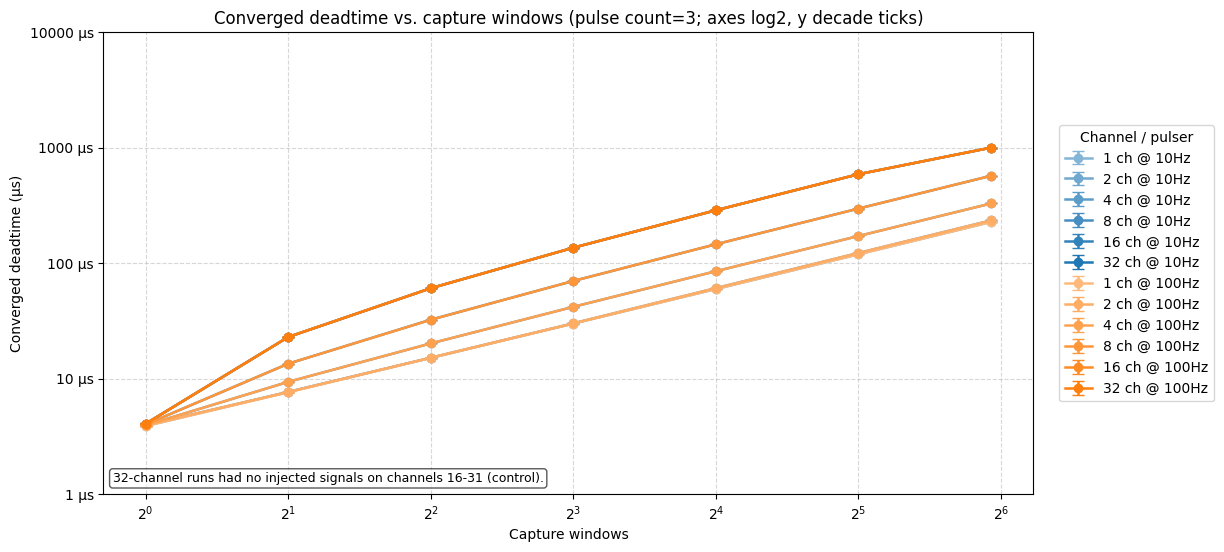

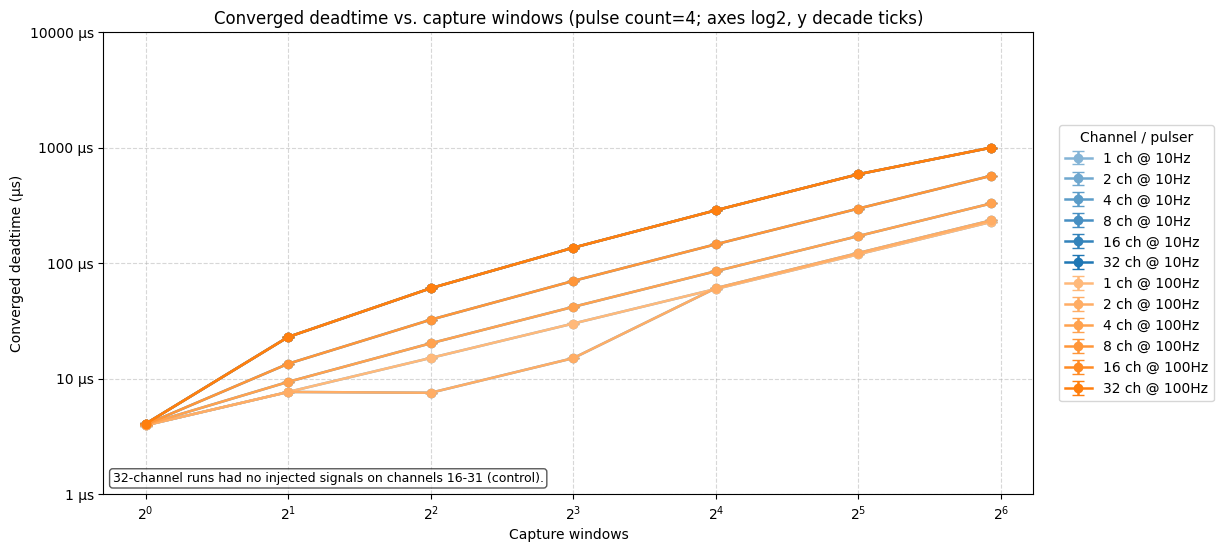

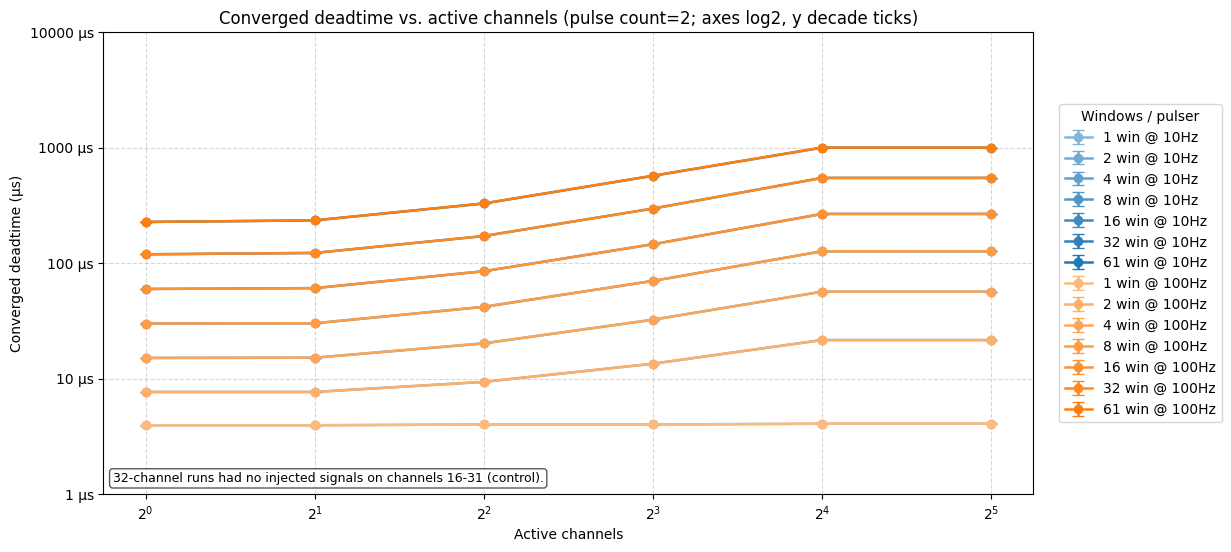

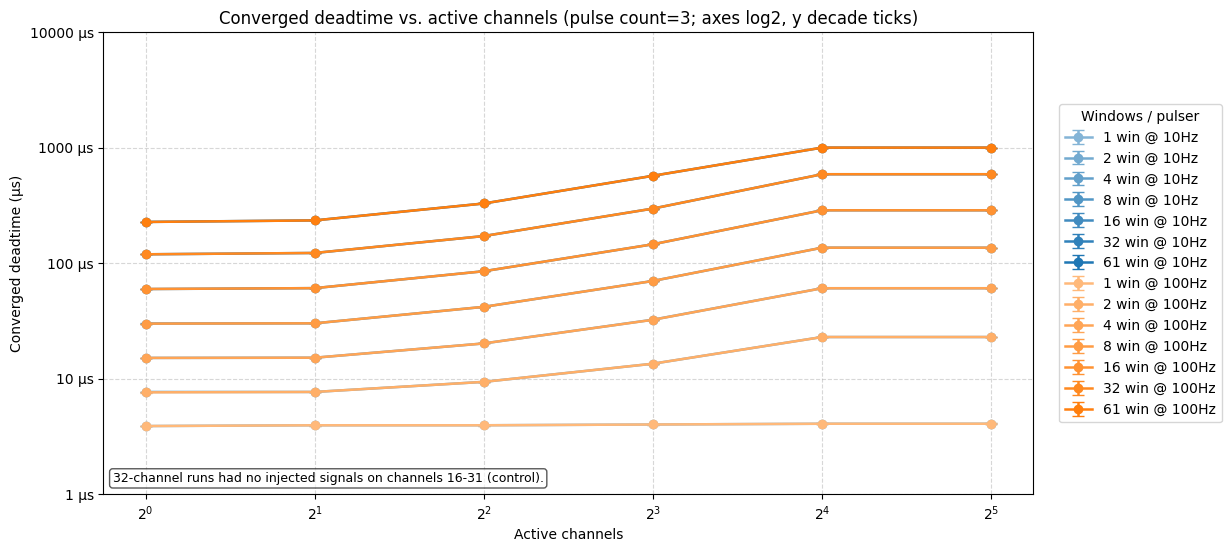

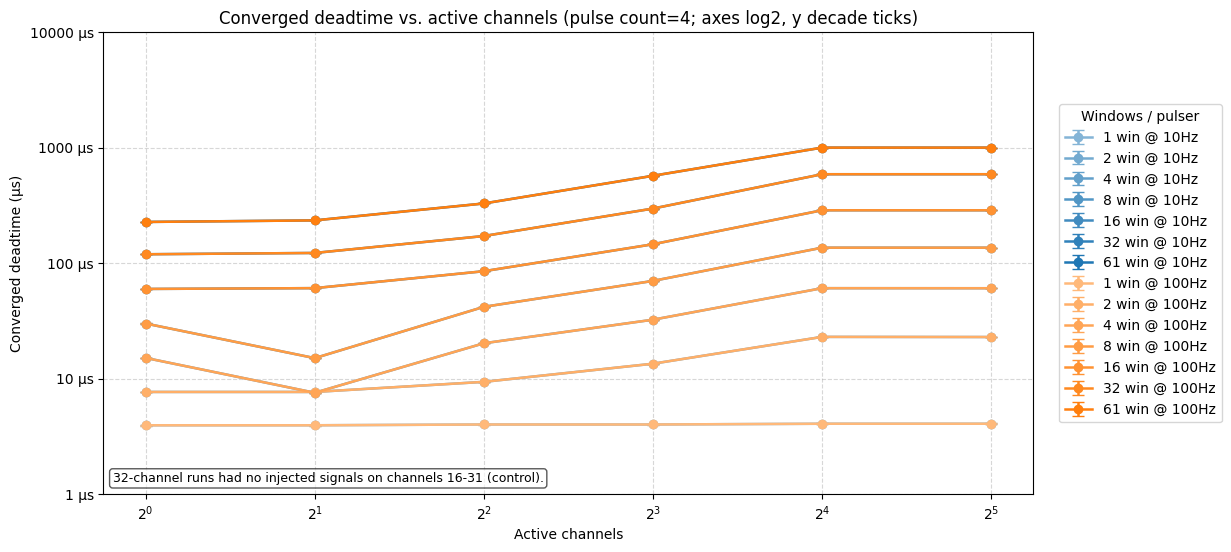

In [4]:

analysis.plot_converged_vs_windows(pulse_rates=PULSER_RATES, pulse_counts=PULSE_COUNTS)
analysis.plot_converged_vs_channels(pulse_rates=PULSER_RATES, pulse_counts=PULSE_COUNTS)


## Minimum separation that yields multi-pulse response
Same view as above but focused on the first separation where we cross into the `double`/multi classification band.

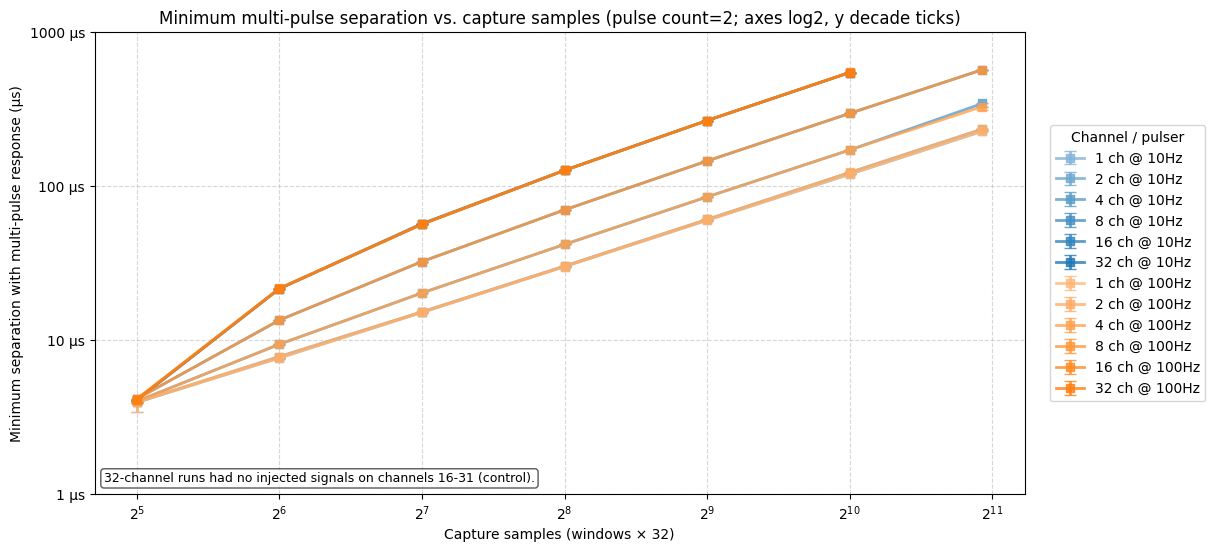

Linear fits for minimum multi-pulse separation (windows on x-axis, pulse count=2):
  1 ch @ 10Hz: separation = 0.116 * samples + 0.28
  2 ch @ 10Hz: separation = 0.120 * samples + -0.21
  4 ch @ 10Hz: separation = 0.176 * samples + -3.31
  8 ch @ 10Hz: separation = 0.295 * samples + -5.36
  16 ch @ 10Hz: separation = 0.547 * samples + -13.26
  32 ch @ 10Hz: separation = 0.547 * samples + -13.40
  1 ch @ 100Hz: separation = 0.116 * samples + 0.28
  2 ch @ 100Hz: separation = 0.120 * samples + -0.24
  4 ch @ 100Hz: separation = 0.169 * samples + -1.40
  8 ch @ 100Hz: separation = 0.295 * samples + -5.36
  16 ch @ 100Hz: separation = 0.547 * samples + -13.35
  32 ch @ 100Hz: separation = 0.547 * samples + -13.40


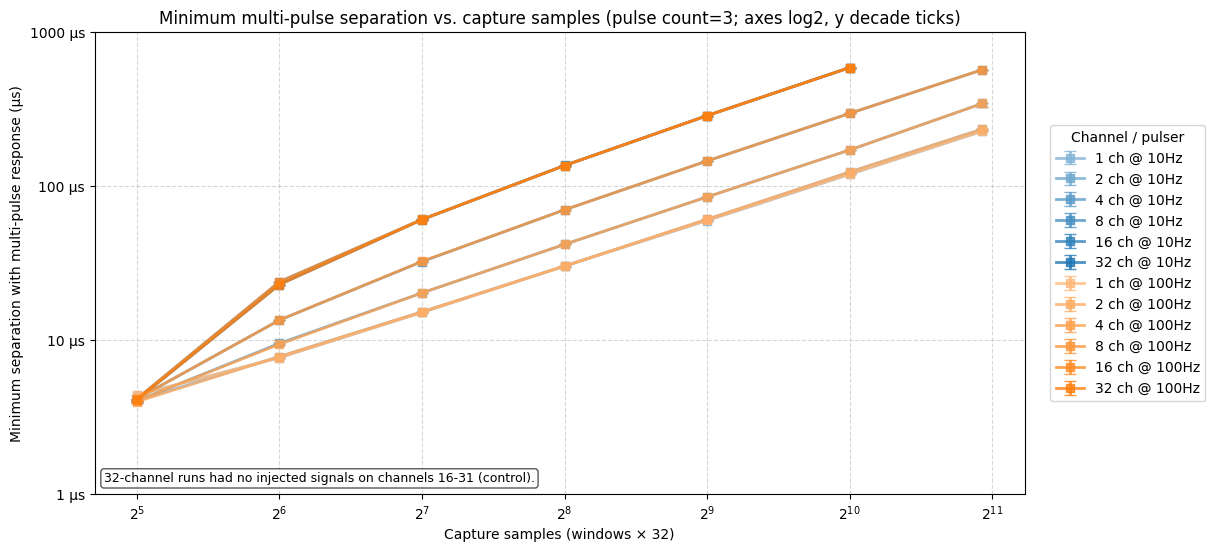

Linear fits for minimum multi-pulse separation (windows on x-axis, pulse count=3):
  1 ch @ 10Hz: separation = 0.116 * samples + 0.39
  2 ch @ 10Hz: separation = 0.120 * samples + -0.16
  4 ch @ 10Hz: separation = 0.176 * samples + -3.27
  8 ch @ 10Hz: separation = 0.295 * samples + -5.35
  16 ch @ 10Hz: separation = 0.589 * samples + -14.39
  32 ch @ 10Hz: separation = 0.589 * samples + -14.74
  1 ch @ 100Hz: separation = 0.116 * samples + 0.44
  2 ch @ 100Hz: separation = 0.120 * samples + -0.11
  4 ch @ 100Hz: separation = 0.176 * samples + -3.30
  8 ch @ 100Hz: separation = 0.295 * samples + -5.33
  16 ch @ 100Hz: separation = 0.589 * samples + -14.41
  32 ch @ 100Hz: separation = 0.589 * samples + -14.74


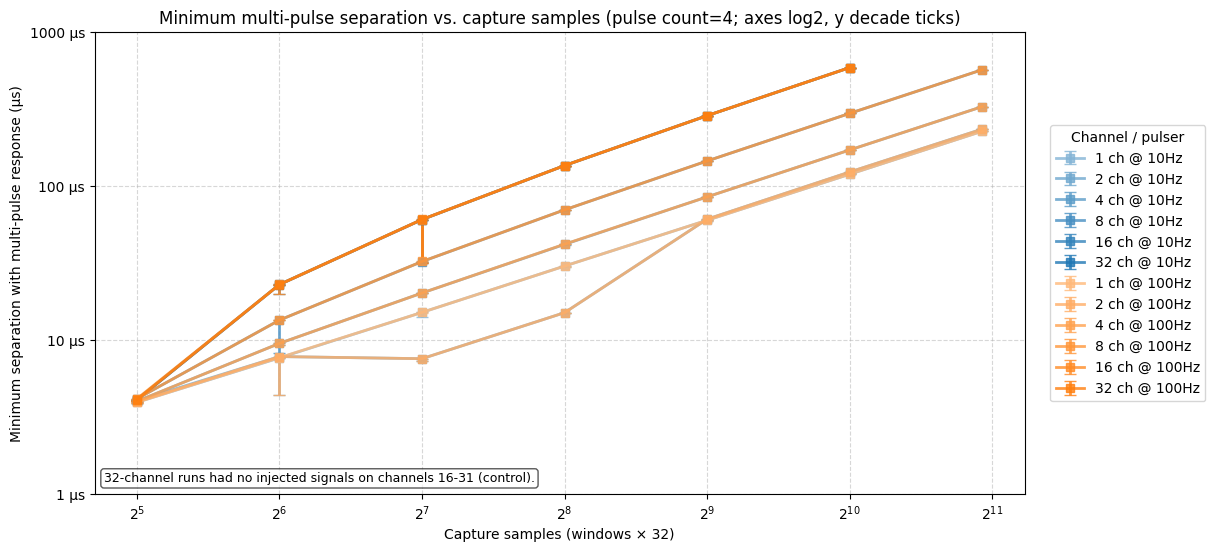

Linear fits for minimum multi-pulse separation (windows on x-axis, pulse count=4):
  1 ch @ 10Hz: separation = 0.116 * samples + 0.31
  2 ch @ 10Hz: separation = 0.123 * samples + -4.95
  4 ch @ 10Hz: separation = 0.169 * samples + -1.37
  8 ch @ 10Hz: separation = 0.295 * samples + -5.36
  16 ch @ 10Hz: separation = 0.589 * samples + -14.74
  32 ch @ 10Hz: separation = 0.589 * samples + -14.75
  1 ch @ 100Hz: separation = 0.116 * samples + 0.33
  2 ch @ 100Hz: separation = 0.123 * samples + -4.92
  4 ch @ 100Hz: separation = 0.169 * samples + -1.35
  8 ch @ 100Hz: separation = 0.295 * samples + -5.35
  16 ch @ 100Hz: separation = 0.589 * samples + -14.72
  32 ch @ 100Hz: separation = 0.589 * samples + -14.71


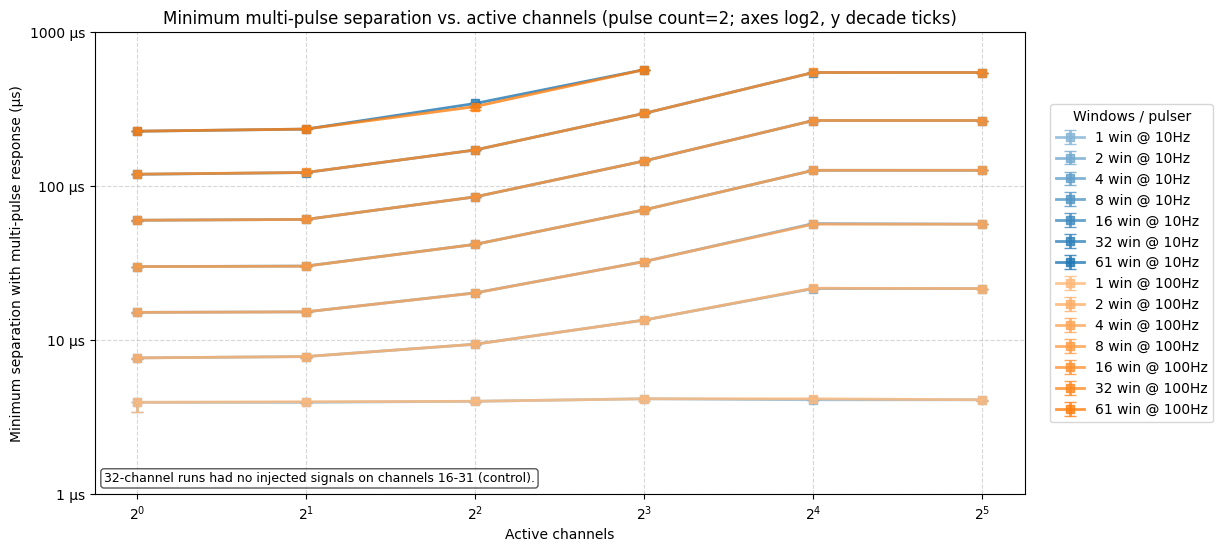

Linear fits for minimum multi-pulse separation (channels on x-axis, pulse count=2):
  1 win @ 10Hz: separation = 0.005 * channels + 4.00
  2 win @ 10Hz: separation = 0.496 * channels + 8.39
  4 win @ 10Hz: separation = 1.486 * channels + 17.19
  8 win @ 10Hz: separation = 3.454 * channels + 34.67
  16 win @ 10Hz: separation = 7.386 * channels + 69.94
  32 win @ 10Hz: separation = 15.251 * channels + 140.47
  61 win @ 10Hz: separation = 51.310 * channels + 151.67
  1 win @ 100Hz: separation = 0.005 * channels + 4.01
  2 win @ 100Hz: separation = 0.497 * channels + 8.40
  4 win @ 100Hz: separation = 1.482 * channels + 17.15
  8 win @ 100Hz: separation = 3.454 * channels + 34.66
  16 win @ 100Hz: separation = 7.385 * channels + 69.96
  32 win @ 100Hz: separation = 15.247 * channels + 140.60
  61 win @ 100Hz: separation = 51.153 * channels + 148.43


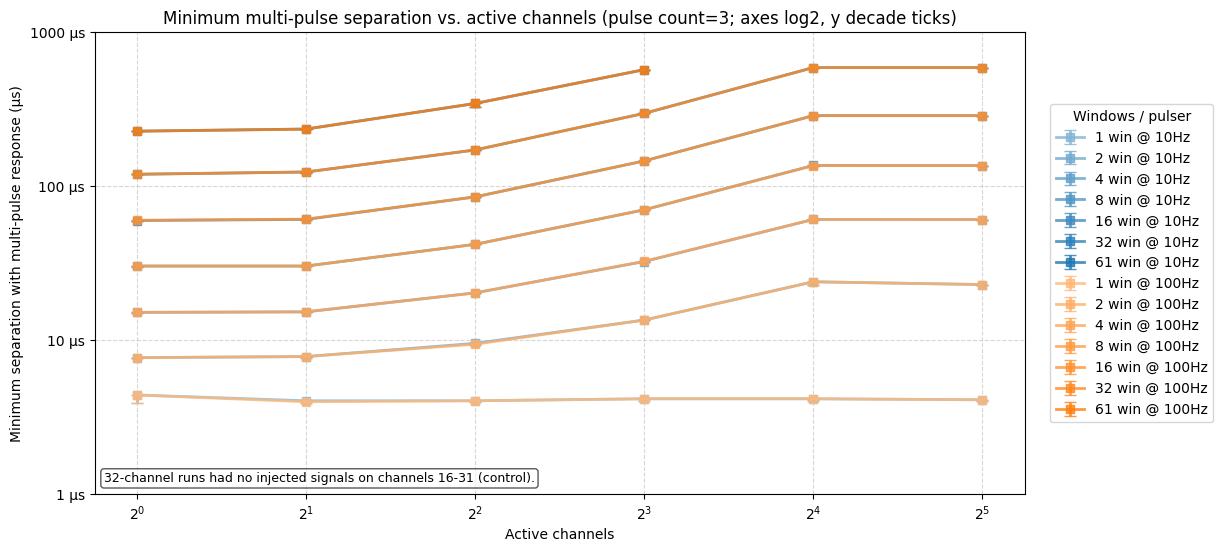

Linear fits for minimum multi-pulse separation (channels on x-axis, pulse count=3):
  1 win @ 10Hz: separation = -0.003 * channels + 4.18
  2 win @ 10Hz: separation = 0.554 * channels + 8.42
  4 win @ 10Hz: separation = 1.637 * channels + 16.88
  8 win @ 10Hz: separation = 3.812 * channels + 34.11
  16 win @ 10Hz: separation = 8.164 * channels + 68.46
  32 win @ 10Hz: separation = 16.839 * channels + 137.88
  61 win @ 10Hz: separation = 51.277 * channels + 151.89
  1 win @ 100Hz: separation = -0.002 * channels + 4.16
  2 win @ 100Hz: separation = 0.555 * channels + 8.39
  4 win @ 100Hz: separation = 1.637 * channels + 16.90
  8 win @ 100Hz: separation = 3.811 * channels + 34.10
  16 win @ 100Hz: separation = 8.157 * channels + 68.61
  32 win @ 100Hz: separation = 16.835 * channels + 137.95
  61 win @ 100Hz: separation = 51.292 * channels + 151.78


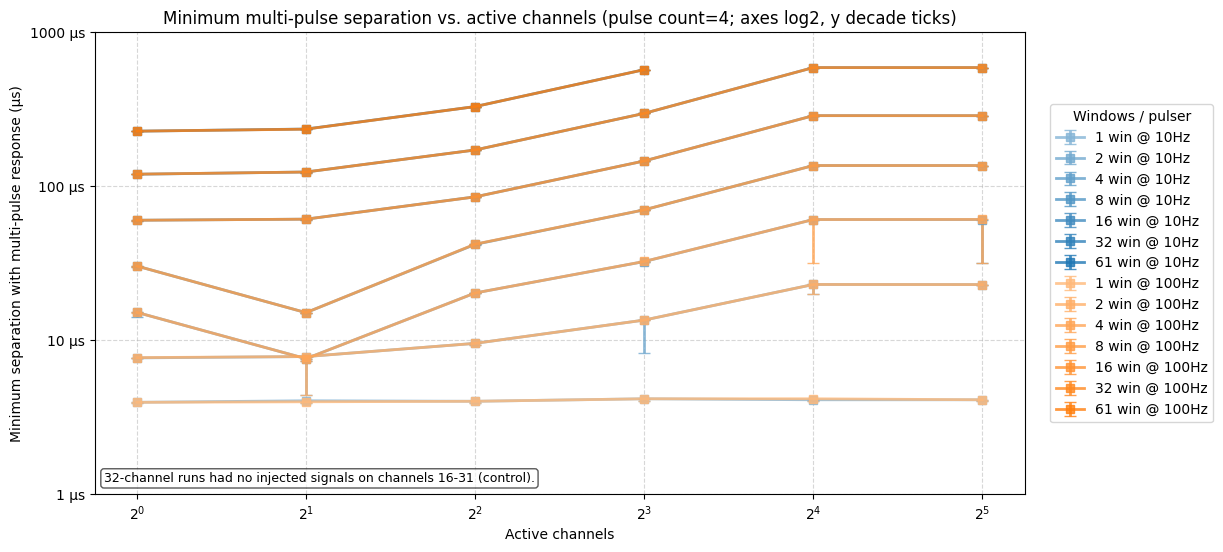

Linear fits for minimum multi-pulse separation (channels on x-axis, pulse count=4):
  1 win @ 10Hz: separation = 0.003 * channels + 4.02
  2 win @ 10Hz: separation = 0.547 * channels + 8.33
  4 win @ 10Hz: separation = 1.730 * channels + 14.61
  8 win @ 10Hz: separation = 3.995 * channels + 29.63
  16 win @ 10Hz: separation = 8.156 * channels + 68.62
  32 win @ 10Hz: separation = 16.837 * channels + 137.91
  61 win @ 10Hz: separation = 51.142 * channels + 148.51
  1 win @ 100Hz: separation = 0.005 * channels + 4.01
  2 win @ 100Hz: separation = 0.547 * channels + 8.34
  4 win @ 100Hz: separation = 1.734 * channels + 14.60
  8 win @ 100Hz: separation = 3.993 * channels + 29.67
  16 win @ 100Hz: separation = 8.156 * channels + 68.62
  32 win @ 100Hz: separation = 16.836 * channels + 137.94
  61 win @ 100Hz: separation = 51.164 * channels + 148.33


In [5]:

analysis.plot_min_double_vs_windows(pulse_rates=PULSER_RATES, pulse_counts=PULSE_COUNTS)
analysis.plot_min_double_vs_channels(pulse_rates=PULSER_RATES, pulse_counts=PULSE_COUNTS)


## Minimum double-response vs. pulse count
Cross-sections that put pulse count on the x-axis and min separation on the y-axis. Choose one dimension for curves and hold the other two fixed to slice the 5D space:
- Curves by channel count (fix pulser + windows)
- Curves by pulser rate (fix channels + windows)
- Curves by capture windows (fix channels + pulser)


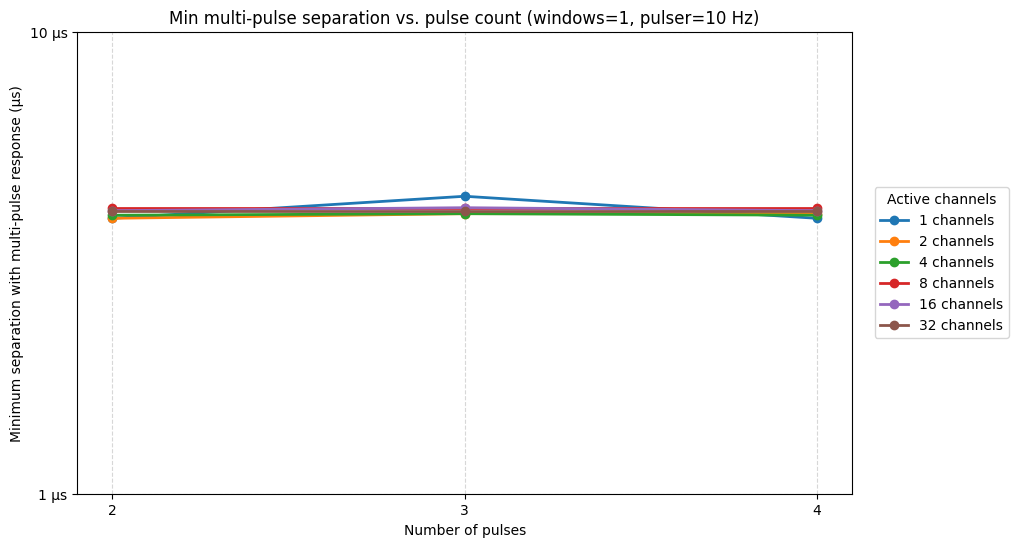

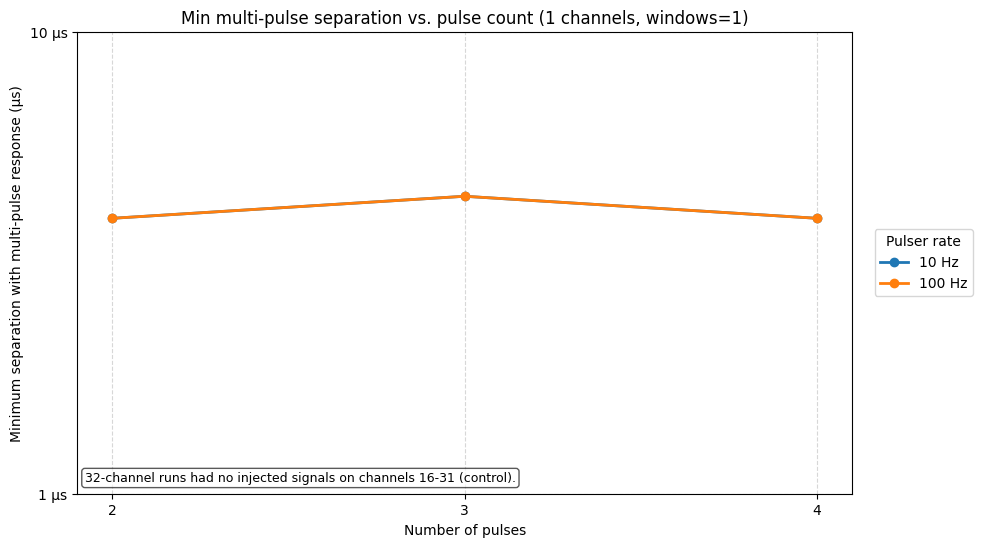

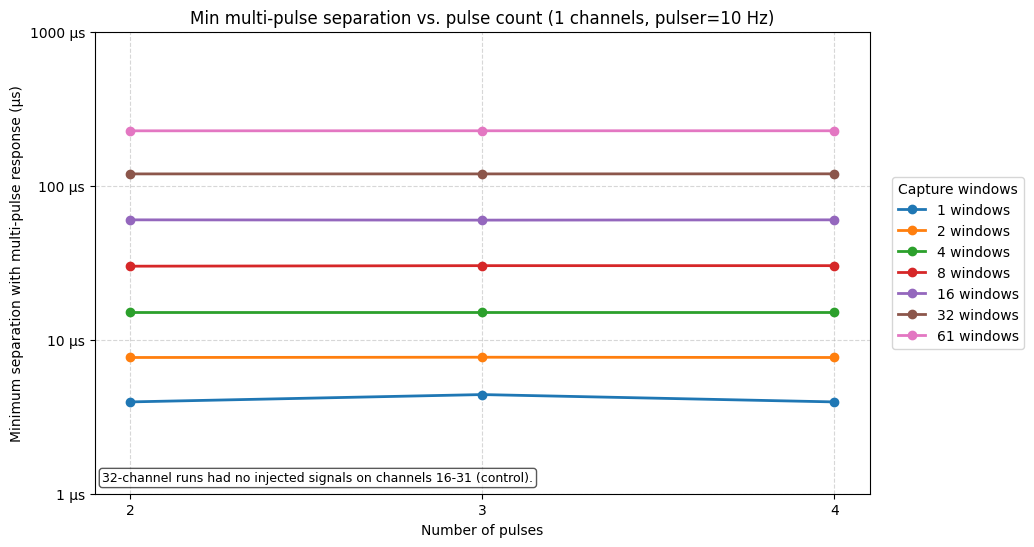

In [6]:

# Choose fixed dimensions for the pulse-count sweeps
PULSE_RATE_FOR_PULSE_SWEEP = 10.0
CHANNELS_FOR_PULSE_SWEEP = 1
WINDOWS_FOR_PULSE_SWEEP = 1

analysis.plot_min_double_vs_pulses_by_channels(pulse_rate_hz=PULSE_RATE_FOR_PULSE_SWEEP, windows=WINDOWS_FOR_PULSE_SWEEP)
analysis.plot_min_double_vs_pulses_by_pulser(channel_count=CHANNELS_FOR_PULSE_SWEEP, windows=WINDOWS_FOR_PULSE_SWEEP)
analysis.plot_min_double_vs_pulses_by_windows(pulse_rate_hz=PULSE_RATE_FOR_PULSE_SWEEP, channel_count=CHANNELS_FOR_PULSE_SWEEP)
